In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Visualization style (paper-ready)
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

# File paths
RESULTS_PATH = "test_detailed_results_buffer2.csv"
LANG_METRICS_PATH = "language_wise_metrics_buffer2.csv"


In [2]:
results_df = pd.read_csv(RESULTS_PATH)
metrics_df = pd.read_csv(LANG_METRICS_PATH)

results_df["is_correct"] = results_df["is_correct"].astype(int)

print("Samples:", len(results_df))
print("Languages:", results_df["lang"].unique())
print("Models:", results_df["model_used"].unique())


Samples: 400
Languages: ['Danish' 'English' 'Spanish' 'Polish' 'Turkish']
Models: ['meta-llama/Llama-3.1-8B' 'CohereLabs/aya-expanse-8b' 'Qwen/Qwen2.5-3B']


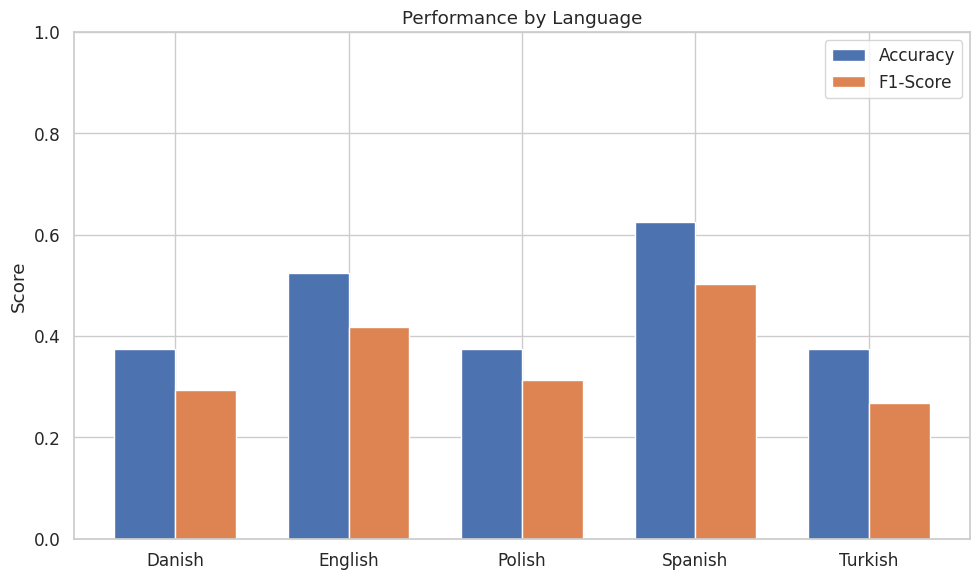

In [3]:
x = np.arange(len(metrics_df))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, metrics_df["Accuracy"], width, label="Accuracy")
ax.bar(x + width/2, metrics_df["F1-Score"], width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Language"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Performance by Language")
ax.legend()

plt.tight_layout()
plt.show()


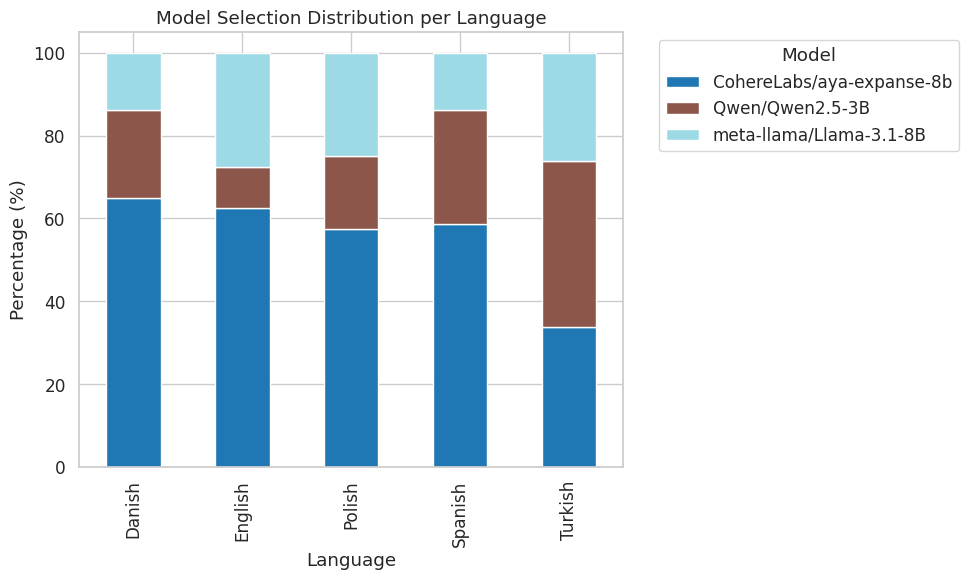

In [4]:
usage = (
    results_df
    .groupby(["lang", "model_used"])
    .size()
    .unstack(fill_value=0)
)

usage_pct = usage.div(usage.sum(axis=1), axis=0) * 100

usage_pct.plot(
    kind="bar",
    stacked=True,
    colormap="tab20"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Language")
plt.title("Model Selection Distribution per Language")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


/tmp/ipykernel_3916939/1171254702.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


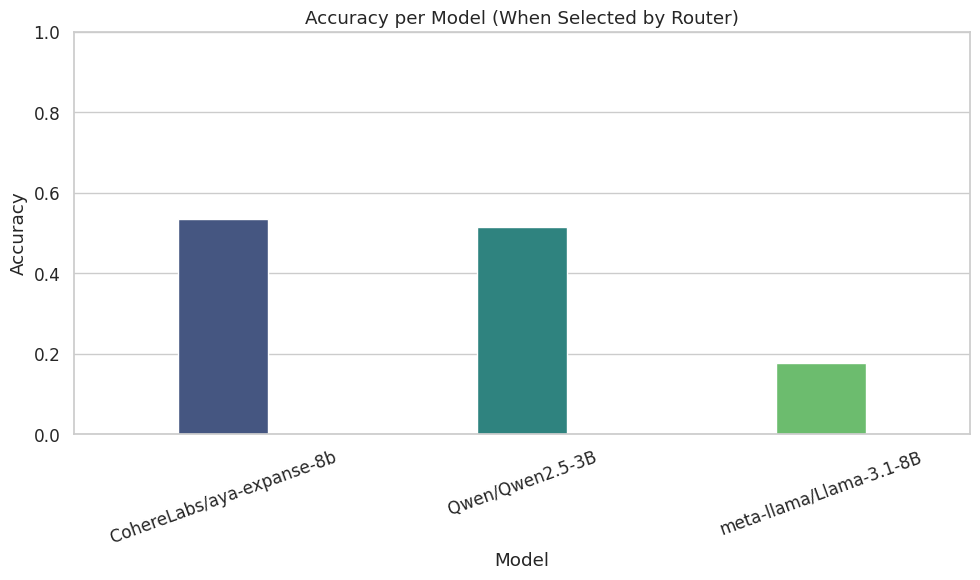

In [9]:
model_acc = (
    results_df
    .groupby("model_used")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=model_acc.index,
    y=model_acc.values,
    palette="viridis",
    width=0.3
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.title("Accuracy per Model (When Selected by Router)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


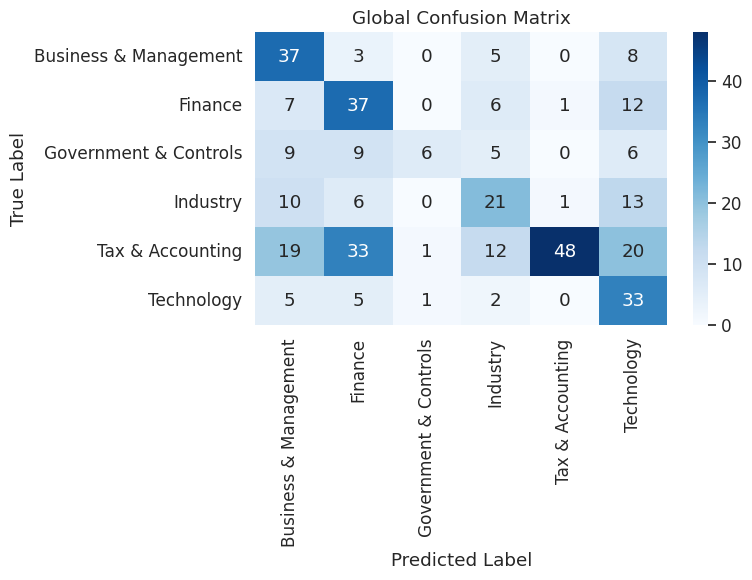

In [6]:
labels = sorted(results_df["true_label"].unique())

cm = confusion_matrix(
    results_df["true_label"],
    results_df["pred_label"],
    labels=labels
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Global Confusion Matrix")

plt.tight_layout()
plt.show()
